In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0
def create_model(lr):
    m=Sequential([Dense(128,activation='relu',input_shape=(784,)),
                  Dense(64,activation='relu'),
                  Dense(10,activation='softmax')])
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0          0.100    0.1992
1          0.010    0.8557
2          0.001    0.8749


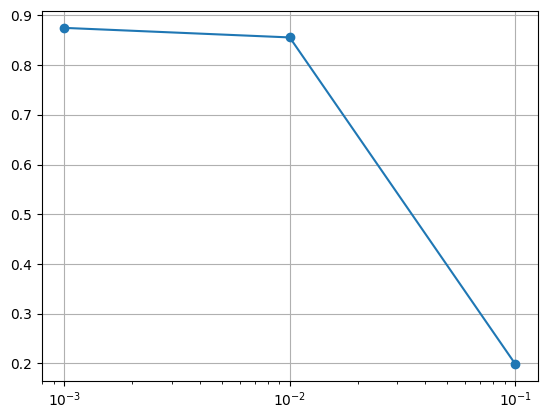

In [ ]:
learning_rates=[0.1,0.01,0.001]
results=[]
for lr in learning_rates:
    model=create_model(lr)
    model.fit(x_train,y_train,epochs=5,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    results.append([lr,acc])
df=pd.DataFrame(results,columns=['Learning Rate','Accuracy'])
print(df)
plt.plot(df['Learning Rate'],df['Accuracy'],marker='o')
plt.xscale('log'); plt.grid(); plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.8677
1      10    0.8809
2      20    0.8861


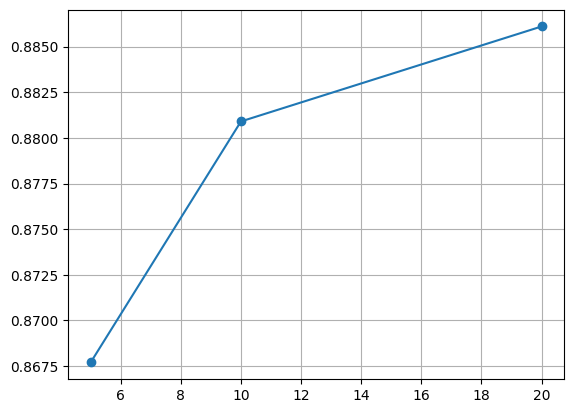

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7980 - loss: 0.5811 - val_accuracy: 0.8312 - val_loss: 0.4611
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8558 - loss: 0.4011 - val_accuracy: 0.8627 - val_loss: 0.3835
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8694 - loss: 0.3609 - val_accuracy: 0.8705 - val_loss: 0.3695
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8796 - loss: 0.3308 - val_accuracy: 0.8726 - val_loss: 0.3500
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8868 - loss: 0.3107 - val_accuracy: 0.8691 - val_loss: 0.3601
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8906 - loss: 0.2970 - val_accuracy: 0.8751 - val_loss: 0.3441
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8958 - loss: 0.2830 - val_accuracy: 0.8822 - val_loss: 0.3267
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9011 - loss: 0.2698 - val_accuracy: 0

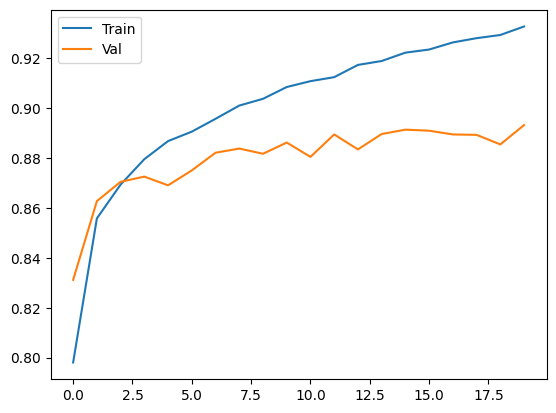

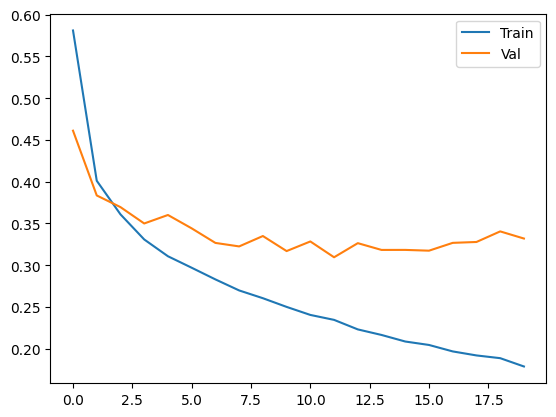

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8896 - loss: 0.3587
[0.3587453067302704, 0.8895999789237976]


In [ ]:
epochs_list=[5,10,20]
res=[]
for ep in epochs_list:
    model=create_model(0.001)
    h=model.fit(x_train,y_train,validation_split=0.2,epochs=ep,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    res.append([ep,acc])
edf=pd.DataFrame(res,columns=['Epochs','Accuracy'])
print(edf)
plt.plot(edf['Epochs'],edf['Accuracy'],marker='o')
plt.grid(); plt.show()

model=create_model(0.001)
history=model.fit(x_train,y_train,validation_split=0.2,epochs=20,batch_size=128)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.legend(['Train','Val']); plt.show()
plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.legend(['Train','Val']); plt.show()
print(model.evaluate(x_test,y_test))